# Use Pytorch to recognize hand-written digits with `ibm-watsonx-ai`

This notebook facilitates Pytorch ML library in watsonx.ai. It contains steps and code to work with [ibm-watsonx-ai](https://pypi.python.org/pypi/ibm-watsonx-ai) library available in PyPI repository. It also introduces commands for getting model and training data, persisting model, deploying model and scoring it.

Some familiarity with Python is helpful. This notebook uses Python 3.12.

## Learning goals

The learning goals of this notebook are:

-  Download an externally trained Pytorch model with dataset.
-  Persist an external model in Watson Machine Learning repository.
-  Deploy model for online scoring using client library.
-  Score sample records using client library.


## Contents

This notebook contains the following parts:

1. [Set up the environment](#1.-Set-up-the-environment)
2. [Download externally created Pytorch model and data](#2.-Download-externally-created-Pytorch-model-and-data)
3. [Persist externally created Pytorch ONNX model](#3.-Persist-externally-created-Pytorch-ONNX-model)
4. [Deploy and score](#4.-Deploy-and-score)
5. [Cleanup](#5.-Cleanup)
6. [Summary and next steps](#6.-Summary-and-next-steps)

<a id="1.-Set-up-the-environment"></a>
## 1. Set up the environment

Before you use the sample code in this notebook, you must perform the following setup tasks:

-  Contact with your IBM Cloud Pak® for Data administrator and ask them for your account credentials

### Install dependencies
**Note:** `ibm-watsonx-ai` documentation can be found <a href="https://ibm.github.io/watsonx-ai-python-sdk/index.html" target="_blank" rel="noopener no referrer">here</a>.

In [1]:
%pip install -U wget | tail -n 1
%pip install -U matplotlib | tail -n 1
%pip install -U ibm-watsonx-ai | tail -n 1

#### Define credentials

Authenticate the watsonx.ai Runtime service on IBM Cloud Pak® for Data. You need to provide the **admin's** `username` and the platform `url`.

In [2]:
username = "PASTE YOUR USERNAME HERE"
url = "PASTE THE PLATFORM URL HERE"

Use the **admin's** `api_key` to authenticate watsonx.ai Runtime services:

In [ ]:
import getpass

from ibm_watsonx_ai import Credentials

credentials = Credentials(
    username=username,
    api_key=getpass.getpass("Enter your watsonx.ai API key and hit enter: "),
    url=url,
    instance_id="openshift",
    version="5.4",
)

Alternatively you can use the **admin's** `password`:

In [3]:
import getpass

from ibm_watsonx_ai import Credentials

if "credentials" not in locals() or not credentials.api_key:
    credentials = Credentials(
        username=username,
        password=getpass.getpass("Enter your watsonx.ai password and hit enter: "),
        url=url,
        instance_id="openshift",
        version="5.4",
    )

#### Create `APIClient` instance

In [4]:
from ibm_watsonx_ai import APIClient

client = APIClient(credentials)

### Working with spaces

First of all, you need to create a space that will be used for your work. If you do not have space already created, you can use `{PLATFORM_URL}/ml-runtime/spaces?context=icp4data` to create one.

- Click New Deployment Space
- Create an empty space
- Go to space `Settings` tab
- Copy `space_id` and paste it below

**Tip**: You can also use SDK to prepare the space for your work. More information can be found [here](https://github.com/IBM/watsonx-ai-samples/blob/master/cpd5.4/notebooks/python_sdk/instance-management/Space%20management.ipynb).

**Action**: Assign space ID below

In [5]:
space_id = "PASTE YOUR SPACE ID HERE"

You can use `list` method to print all existing spaces.

In [ ]:
client.spaces.list(limit=10)

To be able to interact with all resources available in Watson Machine Learning, you need to set **space** which you will be using.

In [6]:
client.set.default_space(space_id)

'SUCCESS'

<a id="2.-Download-externally-created-Pytorch-model-and-data"></a>
## 2. Download externally created Pytorch model and data
In this section, you will download externally created Pytorch models and data used for training it.

In [7]:
import os

import wget

data_dir = "MNIST_DATA"
if not os.path.isdir(data_dir):
    os.mkdir(data_dir)

model_path = os.path.join(data_dir, "mnist_pytorch.tar.gz")
if not os.path.isfile(model_path):
    wget.download(
        "https://github.com/IBM/watsonx-ai-samples/raw/master/cpd5.4/models/pytorch/mnist_pytorch.tar.gz",
        out=data_dir,
    )

In [8]:
data_dir = "MNIST_DATA"
if not os.path.isdir(data_dir):
    os.mkdir(data_dir)

filename = os.path.join(data_dir, "mnist.npz")
if not os.path.isfile(filename):
    wget.download("https://s3.amazonaws.com/img-datasets/mnist.npz", out=data_dir)

In [9]:
import numpy as np

dataset = np.load(filename)
x_test = dataset["x_test"]

<a id="3.-Persist-externally-created-Pytorch-ONNX-model"></a>
## 3. Persist externally created Pytorch ONNX model

In this section, you will learn how to store your model in watsonx.ai repository

### 3.1: Publish model

#### Publish model in watsonx.ai Runtime.

In [10]:
software_spec_id = client.software_specifications.get_id_by_name("onnxruntime_opset_21")

In [11]:
metadata = {
    client.repository.ModelMetaNames.NAME: "External pytorch model",
    client.repository.ModelMetaNames.TYPE: "onnxruntime_1.17",
    client.repository.ModelMetaNames.SOFTWARE_SPEC_UID: software_spec_id,
}

published_model = client.repository.store_model(model=model_path, meta_props=metadata)

### 3.2: Get model details

In [12]:
import json

published_model_id = client.repository.get_model_id(published_model)
model_details = client.repository.get_details(published_model_id)
print(json.dumps(model_details, indent=2))

{
  "metadata": {
    "name": "External pytorch model",
    "space_id": "892f33cd-5522-4944-83c5-9505b801df9b",
    "resource_key": "71ba1275-0431-419a-987b-fca062113ff8",
    "id": "8415f9c2-690e-4d64-aaa2-52e3b3ec68bc",
    "created_at": "2026-04-21T09:47:44Z",
    "rov": {
      "member_roles": {
        "1000331001": {
          "user_iam_id": "1000331001",
          "roles": [
            "OWNER"
          ]
        }
      }
    },
    "owner": "1000331001"
  },
  "entity": {
    "software_spec": {
      "id": "d0b5361f-0810-554e-8d7b-874b5ff799b1"
    },
    "type": "onnxruntime_1.17"
  }
}


### 3.3 Get all models

In [13]:
models_details = client.repository.list_models()

<a id="4.-Deploy-and-score"></a>
## 4. Deploy and score

In this section you will learn how to create online scoring and to score a new data record by using the IBM Watson Machine Learning SDK.

### 4.1: Create model deployment

#### Create online deployment for published model

In [14]:
metadata = {
    client.deployments.ConfigurationMetaNames.NAME: "Deployment of external pytorch model",
    client.deployments.ConfigurationMetaNames.ONLINE: {},
}

created_deployment = client.deployments.create(published_model_id, meta_props=metadata)



######################################################################################

Synchronous deployment creation for id: '8415f9c2-690e-4d64-aaa2-52e3b3ec68bc' started

######################################################################################


initializing
Note: online_url is deprecated and will be removed in a future release. Use serving_urls instead.
.....
ready


-----------------------------------------------------------------------------------------------
Successfully finished deployment creation, deployment_id='494f06c5-eadd-40fd-954e-2d27dfd13a89'
-----------------------------------------------------------------------------------------------




**Note**: Here we use deployment url saved in `published_model` object. In next section, we show how to retrieve deployment URL from watsonx.ai.

In [15]:
deployment_id = client.deployments.get_id(created_deployment)

Now you can print an online scoring endpoint. 

In [16]:
scoring_endpoint = client.deployments.get_scoring_href(created_deployment)
print(scoring_endpoint)

You can also list existing deployments.

In [17]:
client.deployments.list()

,ID,NAME,STATE,CREATED,ARTIFACT_TYPE,SPEC_STATE,SPEC_REPLACEMENT
0,494f06c5-eadd-40fd-954e-2d27dfd13a89,Deployment of external pytorch model,ready,2026-04-21T09:50:46.889Z,model,supported,


### 4.2: Get deployment details

In [18]:
client.deployments.get_details(deployment_id)

### 4.3: Score

You can use below method to do test scoring request against deployed model.

Let's first visualize two samples from dataset, we'll use for scoring.

In [19]:
%matplotlib inline
import matplotlib.pyplot as plt

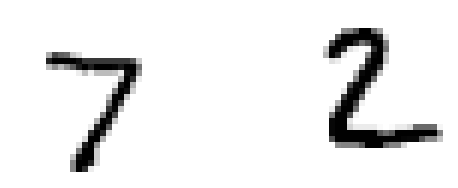

In [20]:
for i, image in enumerate([x_test[0], x_test[1]]):
    plt.subplot(2, 2, i + 1)
    plt.axis("off")
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")

Prepare scoring payload with records to score.

In [21]:
score_0 = [x_test[0].tolist()]
score_1 = [x_test[1].tolist()]

In [22]:
scoring_payload = {"input_data": [{"values": [score_0, score_1]}]}

Use ``client.deployments.score()`` method to run scoring.

In [23]:
predictions = client.deployments.score(deployment_id, scoring_payload)

Let's print the result of predictions.

In [24]:
print(json.dumps(predictions, indent=2))

{
  "predictions": [
    {
      "id": "output",
      "values": [
        [
          0.0,
          0.0,
          0.0,
          0.0,
          0.0,
          0.0,
          0.0,
          1.0,
          0.0,
          0.0
        ],
        [
          0.0,
          0.0,
          1.0,
          0.0,
          0.0,
          0.0,
          0.0,
          0.0,
          0.0,
          0.0
        ]
      ]
    }
  ]
}


As you can see, prediction probabilities point to proper classes as displayed above from test dataset.

<a id="5.-Cleanup"></a>
## 5. Cleanup

If you want to clean up all created assets:
- experiments
- trainings
- pipelines
- model definitions
- models
- functions
- deployments

please follow up this sample [notebook](https://github.com/IBM/watsonx-ai-samples/blob/master/cpd5.4/notebooks/python_sdk/instance-management/Machine%20Learning%20artifacts%20management.ipynb).

<a id="6.-Summary-and-next-steps"></a>
## 6. Summary and next steps

 You successfully completed this notebook! You learned how to use Pytorch machine learning library as well as Watson Machine Learning for model creation and deployment. 
 
 
Check out our _<a href="https://ibm.github.io/watsonx-ai-python-sdk/samples.html" target="_blank" rel="noopener no referrer">Online Documentation</a>_ for more samples, tutorials, documentation, how-tos, and blog posts. 

### Authors

**Daniel Ryszka**, Software Engineer

**Rafał Chrzanowski**, Software Engineer at watsonx.ai

Copyright © 2020-2026 IBM. This notebook and its source code are released under the terms of the MIT License.